# Notebook 03: Baseline Classifier — Main19

This notebook trains a reproducible EfficientNet-B0 baseline for the 19-class
multi-crop disease-classification task.

Data-use protocol:

- Training: `main19_train.csv` only
- Model selection and early stopping: `main19_calibration.csv` only
- Internal test: not loaded in this notebook
- Class weights: calculated from training data only

This run is provisional until the complete near-duplicate manual audit from
Notebook 02 is finalised.

In [1]:
import os
import gc
import json
import random
import platform
from pathlib import Path
from datetime import datetime, timezone
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report
)

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 7

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

Device: cuda
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
GPU: Tesla T4
GPU count: 2


In [2]:
INPUT_ROOT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")

OUTPUT_DIR = WORK_DIR / "baseline_main19_outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
METADATA_DIR = OUTPUT_DIR / "metadata"

for folder in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    FIG_DIR,
    TABLE_DIR,
    METADATA_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Input root:", INPUT_ROOT)
print("Output directory:", OUTPUT_DIR)

Input root: /kaggle/input
Output directory: /kaggle/working/baseline_main19_outputs


In [3]:
def find_input_file(file_name):
    matches = list(INPUT_ROOT.rglob(file_name))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find '{file_name}' under /kaggle/input.\n"
            "Attach the Notebook-02 split_outputs dataset."
        )

    if len(matches) > 1:
        print(f"Multiple matches found for {file_name}:")
        for match in matches:
            print(" -", match)
        print("\nUsing:", matches[0])

    return matches[0]


TRAIN_MANIFEST_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv"
CALIBRATION_MANIFEST_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv"
CLASS_MAPPING_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json"
PROTOCOL_PATH = "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/data_protocol.json"

print("Train manifest:", TRAIN_MANIFEST_PATH)
print("Calibration manifest:", CALIBRATION_MANIFEST_PATH)
print("Class mapping:", CLASS_MAPPING_PATH)
print("Data protocol:", PROTOCOL_PATH)

Train manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv
Calibration manifest: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv
Class mapping: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json
Data protocol: /kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/data_protocol.json


In [4]:
train_df = pd.read_csv(TRAIN_MANIFEST_PATH)
calibration_df = pd.read_csv(CALIBRATION_MANIFEST_PATH)

with open(CLASS_MAPPING_PATH, "r") as file:
    class_to_index = json.load(file)

with open(PROTOCOL_PATH, "r") as file:
    data_protocol = json.load(file)

class_to_index = {
    str(label): int(index)
    for label, index in class_to_index.items()
}

index_to_class = {
    index: label
    for label, index in class_to_index.items()
}

NUM_CLASSES = len(class_to_index)

print("Train shape:", train_df.shape)
print("Calibration shape:", calibration_df.shape)
print("Classes:", NUM_CLASSES)

required_columns = {
    "image_path",
    "label",
    "final_split"
}

missing_train_columns = required_columns - set(train_df.columns)
missing_calibration_columns = required_columns - set(calibration_df.columns)

assert not missing_train_columns, (
    f"Training manifest missing columns: {missing_train_columns}"
)

assert not missing_calibration_columns, (
    f"Calibration manifest missing columns: {missing_calibration_columns}"
)

assert set(train_df["final_split"]) == {"train"}
assert set(calibration_df["final_split"]) == {"calibration"}

assert train_df["label"].nunique() == 19
assert calibration_df["label"].nunique() == 19
assert NUM_CLASSES == 19

assert set(train_df["label"]) == set(class_to_index)
assert set(calibration_df["label"]) == set(class_to_index)

assert set(train_df["image_path"]).isdisjoint(
    set(calibration_df["image_path"])
), "Train and calibration images overlap."

assert train_df["image_path"].nunique() == len(train_df)
assert calibration_df["image_path"].nunique() == len(calibration_df)

assert set(class_to_index.values()) == set(range(NUM_CLASSES))

print("\nPASS: Main19 train/calibration manifests are valid and disjoint.")
print("Internal-test data are intentionally not loaded in Notebook 03.")

Train shape: (18113, 21)
Calibration shape: (3197, 21)
Classes: 19

PASS: Main19 train/calibration manifests are valid and disjoint.
Internal-test data are intentionally not loaded in Notebook 03.


In [5]:
train_exists = train_df["image_path"].map(lambda path: Path(path).exists())
calibration_exists = calibration_df["image_path"].map(
    lambda path: Path(path).exists()
)

print("Existing train image paths:", int(train_exists.sum()), "/", len(train_df))
print(
    "Existing calibration image paths:",
    int(calibration_exists.sum()),
    "/",
    len(calibration_df)
)

assert train_exists.all(), (
    f"{int((~train_exists).sum())} train image paths do not exist."
)

assert calibration_exists.all(), (
    f"{int((~calibration_exists).sum())} calibration image paths do not exist."
)

print("\nPASS: All required image files exist.")

Existing train image paths: 18113 / 18113
Existing calibration image paths: 3197 / 3197

PASS: All required image files exist.


In [6]:
input_record = {
    "notebook": "03_baseline_classifier_main19",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "seed": SEED,
    "train_manifest": str(TRAIN_MANIFEST_PATH),
    "calibration_manifest": str(CALIBRATION_MANIFEST_PATH),
    "class_mapping": str(CLASS_MAPPING_PATH),
    "train_images": int(len(train_df)),
    "calibration_images": int(len(calibration_df)),
    "num_classes": int(NUM_CLASSES),
    "test_data_loaded": False,
    "data_protocol_near_duplicate_exclusions": data_protocol.get(
        "confirmed_near_duplicate_exclusions",
        "not_recorded"
    )
}

with open(METADATA_DIR / "input_data_record.json", "w") as file:
    json.dump(input_record, file, indent=2)

print(json.dumps(input_record, indent=2))

{
  "notebook": "03_baseline_classifier_main19",
  "created_utc": "2026-08-12T06:46:48.381253+00:00",
  "seed": 7,
  "train_manifest": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_train.csv",
  "calibration_manifest": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/manifests/main19/main19_calibration.csv",
  "class_mapping": "/kaggle/input/datasets/katakuricharlotte/crop-manifestfiles/split_outputs/split_outputs/metadata/class_to_index_main19.json",
  "train_images": 18113,
  "calibration_images": 3197,
  "num_classes": 19,
  "test_data_loaded": false,
  "data_protocol_near_duplicate_exclusions": 2
}


In [7]:
class_counts = (
    train_df["label"]
    .value_counts()
    .reindex(sorted(class_to_index, key=class_to_index.get))
)

class_weight_values = len(train_df) / (
    NUM_CLASSES * class_counts.values.astype(np.float32)
)

class_weights = torch.tensor(
    class_weight_values,
    dtype=torch.float32,
    device=DEVICE
)

class_weight_df = pd.DataFrame({
    "class_index": [class_to_index[label] for label in class_counts.index],
    "label": class_counts.index,
    "train_images": class_counts.values,
    "cross_entropy_weight": class_weight_values
})

class_weight_path = TABLE_DIR / "training_class_weights.csv"
class_weight_df.to_csv(class_weight_path, index=False)

display(class_weight_df)

print("Smallest training class:", class_counts.min())
print("Largest training class:", class_counts.max())
print("Largest/smallest ratio:", round(class_counts.max() / class_counts.min(), 2))
print("Saved:", class_weight_path)

,class_index,label,train_images,cross_entropy_weight
0,0,bell_pepper__bacterial_spot,677,1.408147
1,1,bell_pepper__healthy,1005,0.948573
2,2,corn__cercospora_leaf_spot_gray_leaf_spot,348,2.739413
3,3,corn__common_rust,810,1.176933
4,4,corn__healthy,790,1.206729
5,5,corn__northern_leaf_blight,670,1.422859
6,6,potato__early_blight,680,1.401935
7,7,potato__healthy,103,9.255493
8,8,potato__late_blight,680,1.401935
9,9,tomato__bacterial_spot,1447,0.658822


Smallest training class: 103
Largest training class: 3643
Largest/smallest ratio: 35.37
Saved: /kaggle/working/baseline_main19_outputs/tables/training_class_weights.csv


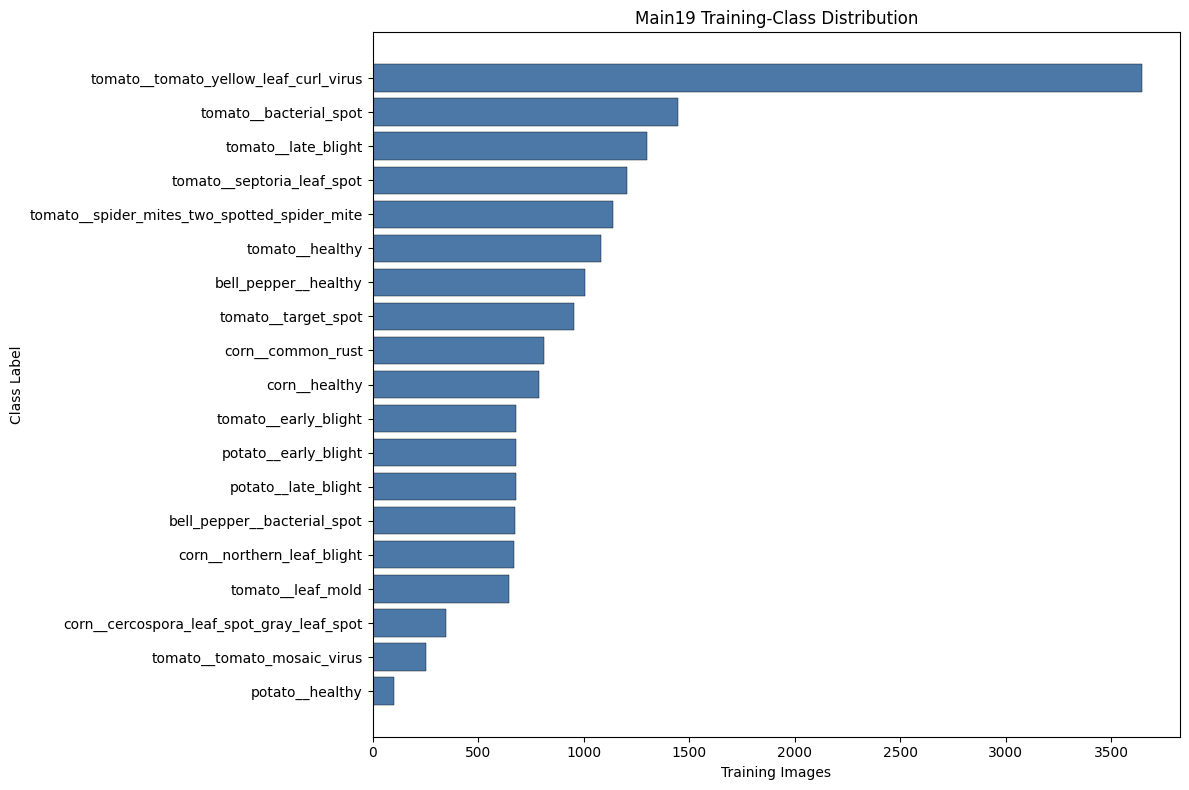

Saved: /kaggle/working/baseline_main19_outputs/figures/fig_01_main19_training_distribution.png


In [8]:
plot_df = class_weight_df.sort_values("train_images", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(
    plot_df["label"],
    plot_df["train_images"],
    color="#4C78A8",
    edgecolor="black",
    linewidth=0.3
)

plt.title("Main19 Training-Class Distribution")
plt.xlabel("Training Images")
plt.ylabel("Class Label")
plt.tight_layout()

class_distribution_path = FIG_DIR / "fig_01_main19_training_distribution.png"
plt.savefig(class_distribution_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", class_distribution_path)

In [9]:
IMAGE_SIZE = 224

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.03
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

EVAL_TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image size:", IMAGE_SIZE)

Image size: 224


In [10]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, dataframe, class_to_index, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.class_to_index = class_to_index
        self.transform = transform

        self.image_paths = self.dataframe["image_path"].tolist()
        self.labels = self.dataframe["label"].tolist()
        self.targets = [
            self.class_to_index[label]
            for label in self.labels
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        target = self.targets[index]

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")
        except Exception as error:
            raise RuntimeError(
                f"Could not load image at index {index}: {image_path}"
            ) from error

        image = self.transform(image)

        return {
            "image": image,
            "target": torch.tensor(target, dtype=torch.long),
            "path": image_path
        }


train_dataset = PlantDiseaseDataset(
    dataframe=train_df,
    class_to_index=class_to_index,
    transform=TRAIN_TRANSFORM
)

calibration_dataset = PlantDiseaseDataset(
    dataframe=calibration_df,
    class_to_index=class_to_index,
    transform=EVAL_TRANSFORM
)

print("Train dataset:", len(train_dataset))
print("Calibration dataset:", len(calibration_dataset))

Train dataset: 18113
Calibration dataset: 3197


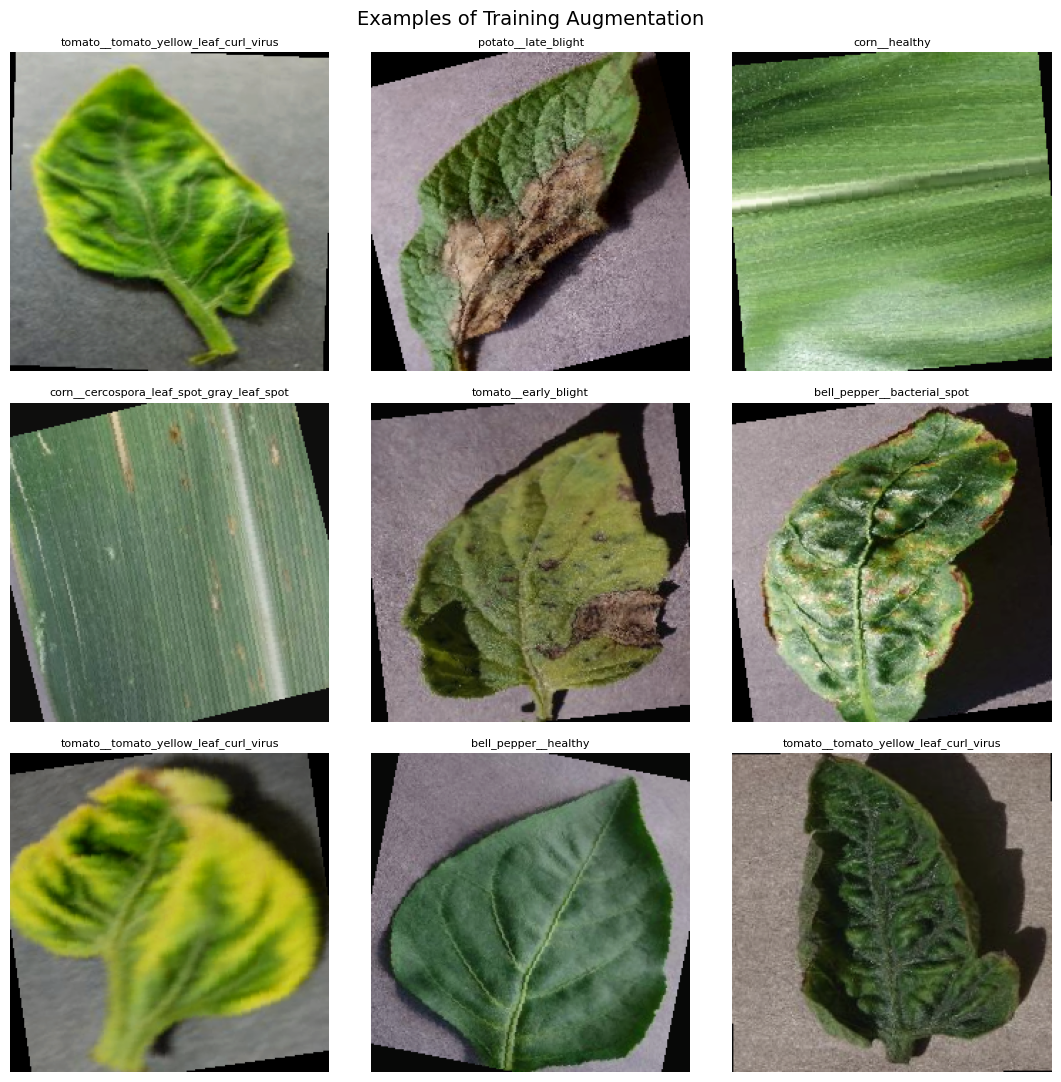

Saved: /kaggle/working/baseline_main19_outputs/figures/fig_02_training_augmentation_examples.png


In [11]:
inverse_normalize = transforms.Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225]
)

sample_indices = np.random.choice(
    len(train_dataset),
    size=9,
    replace=False
)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for axis, sample_index in zip(axes.flat, sample_indices):
    sample = train_dataset[sample_index]
    image = inverse_normalize(sample["image"]).clamp(0, 1)
    class_name = index_to_class[int(sample["target"])]

    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(class_name, fontsize=8)
    axis.axis("off")

plt.suptitle("Examples of Training Augmentation", fontsize=14)
plt.tight_layout()

augmentation_preview_path = FIG_DIR / "fig_02_training_augmentation_examples.png"
plt.savefig(augmentation_preview_path, dpi=250, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", augmentation_preview_path)

In [12]:
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == "cuda"

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
    generator=generator
)

calibration_loader = DataLoader(
    calibration_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0
)

print("Batch size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)
print("Training batches:", len(train_loader))
print("Calibration batches:", len(calibration_loader))

Batch size: 32
Workers: 4
Training batches: 567
Calibration batches: 100


In [13]:
try:
    efficientnet_weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1

    model = models.efficientnet_b0(
        weights=efficientnet_weights
    )

    print("Loaded ImageNet-pretrained EfficientNet-B0 weights.")

except Exception as error:
    raise RuntimeError(
        "Could not load ImageNet-pretrained EfficientNet-B0 weights. "
        "Attach a Kaggle EfficientNet-B0 model resource or enable Internet "
        "for this notebook, then rerun."
    ) from error

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s] 


Loaded ImageNet-pretrained EfficientNet-B0 weights.
Total parameters: 4,031,887
Trainable parameters: 4,031,887
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=19, bias=True)
)


In [14]:
EPOCHS = 15
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=DEVICE.type == "cuda"
)

training_config = {
    "architecture": "EfficientNet-B0",
    "pretrained_weights": "IMAGENET1K_V1",
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs_maximum": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "loss": "class-weighted cross-entropy",
    "selection_metric": "calibration macro-F1",
    "seed": SEED,
    "device": str(DEVICE)
}

with open(METADATA_DIR / "training_config.json", "w") as file:
    json.dump(training_config, file, indent=2)

print(json.dumps(training_config, indent=2))

{
  "architecture": "EfficientNet-B0",
  "pretrained_weights": "IMAGENET1K_V1",
  "num_classes": 19,
  "image_size": 224,
  "batch_size": 32,
  "epochs_maximum": 15,
  "learning_rate": 0.0003,
  "weight_decay": 0.0001,
  "early_stopping_patience": 4,
  "loss": "class-weighted cross-entropy",
  "selection_metric": "calibration macro-F1",
  "seed": 7,
  "device": "cuda"
}


In [15]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()

    running_loss = 0.0
    all_targets = []
    all_predictions = []

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda"
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)

        all_targets.extend(targets.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(all_targets, all_predictions)
    epoch_macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "macro_f1": epoch_macro_f1
    }


@torch.no_grad()
def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_targets = []
    all_predictions = []
    all_probabilities = []
    all_paths = []

    progress_bar = tqdm(
        loader,
        desc="Calibration",
        leave=False
    )

    for batch in progress_bar:
        images = batch["image"].to(device, non_blocking=True)
        targets = batch["target"].to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type=device.type,
            enabled=device.type == "cuda"
        ):
            logits = model(images)
            loss = criterion(logits, targets)

        probabilities = torch.softmax(logits, dim=1)
        predictions = probabilities.argmax(dim=1)

        running_loss += loss.item() * images.size(0)

        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.append(probabilities.cpu().numpy())
        all_paths.extend(batch["path"])

    all_probabilities = np.concatenate(all_probabilities, axis=0)

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_targets, all_predictions),
        "balanced_accuracy": balanced_accuracy_score(
            all_targets,
            all_predictions
        ),
        "macro_f1": f1_score(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0
        )
    }

    outputs = {
        "targets": np.array(all_targets),
        "predictions": np.array(all_predictions),
        "probabilities": all_probabilities,
        "paths": all_paths
    }

    return metrics, outputs

In [16]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)

if DEVICE.type == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    capability = torch.cuda.get_device_capability(0)

    print("GPU:", gpu_name)
    print("CUDA capability:", capability)

    assert capability >= (7, 0), (
        f"{gpu_name} has capability {capability}, but this PyTorch build "
        "requires CUDA capability 7.0 or newer. Select T4 rather than P100 "
        "in Kaggle notebook settings, then restart the session."
    )

Device: cuda
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
GPU: Tesla T4
CUDA capability: (7, 5)


In [17]:
best_macro_f1 = -np.inf
best_epoch = 0
epochs_without_improvement = 0
history = []

best_checkpoint_path = CHECKPOINT_DIR / "best_efficientnet_b0_main19.pt"

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'=' * 72}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"{'=' * 72}")

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE
    )

    calibration_metrics, calibration_outputs = evaluate_model(
        model=model,
        loader=calibration_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(calibration_metrics["macro_f1"])

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_record = {
        "epoch": epoch,
        "learning_rate": current_lr,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "calibration_loss": calibration_metrics["loss"],
        "calibration_accuracy": calibration_metrics["accuracy"],
        "calibration_balanced_accuracy": calibration_metrics[
            "balanced_accuracy"
        ],
        "calibration_macro_f1": calibration_metrics["macro_f1"]
    }

    history.append(epoch_record)

    print(
        f"Train loss: {train_metrics['loss']:.4f} | "
        f"Train accuracy: {train_metrics['accuracy']:.4f} | "
        f"Train macro-F1: {train_metrics['macro_f1']:.4f}"
    )

    print(
        f"Calibration loss: {calibration_metrics['loss']:.4f} | "
        f"Calibration accuracy: {calibration_metrics['accuracy']:.4f} | "
        f"Calibration balanced accuracy: "
        f"{calibration_metrics['balanced_accuracy']:.4f} | "
        f"Calibration macro-F1: {calibration_metrics['macro_f1']:.4f}"
    )

    if calibration_metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = calibration_metrics["macro_f1"]
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_calibration_macro_f1": best_macro_f1,
            "class_to_index": class_to_index,
            "training_config": training_config,
            "input_record": input_record
        }

        torch.save(checkpoint, best_checkpoint_path)

        print(
            f"Saved new best checkpoint "
            f"(calibration macro-F1 = {best_macro_f1:.4f})."
        )

    else:
        epochs_without_improvement += 1

        print(
            f"No macro-F1 improvement for "
            f"{epochs_without_improvement} epoch(s)."
        )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping triggered.")
        break

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

history_df = pd.DataFrame(history)

history_path = TABLE_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best calibration macro-F1:", round(best_macro_f1, 5))
print("Checkpoint:", best_checkpoint_path)
print("History:", history_path)


Epoch 1/15


Training:   0%|          | 0/567 [00:00<?, ?it/s]

Calibration:   0%|          | 0/100 [00:00<?, ?it/s]

Train loss: 0.3904 | Train accuracy: 0.8975 | Train macro-F1: 0.8820
Calibration loss: 0.1016 | Calibration accuracy: 0.9722 | Calibration balanced accuracy: 0.9667 | Calibration macro-F1: 0.9678
Saved new best checkpoint (calibration macro-F1 = 0.9678).

Epoch 2/15


Training:   0%|          | 0/567 [00:00<?, ?it/s]

...

Calibration:   0%|          | 0/100 [00:00<?, ?it/s]

Train loss: 0.0056 | Train accuracy: 0.9985 | Train macro-F1: 0.9983
Calibration loss: 0.0349 | Calibration accuracy: 0.9953 | Calibration balanced accuracy: 0.9937 | Calibration macro-F1: 0.9935
Saved new best checkpoint (calibration macro-F1 = 0.9935).

Epoch 15/15


Training:   0%|          | 0/567 [00:00<?, ?it/s]

Calibration:   0%|          | 0/100 [00:00<?, ?it/s]

Train loss: 0.0053 | Train accuracy: 0.9985 | Train macro-F1: 0.9981
Calibration loss: 0.0385 | Calibration accuracy: 0.9959 | Calibration balanced accuracy: 0.9939 | Calibration macro-F1: 0.9940
Saved new best checkpoint (calibration macro-F1 = 0.9940).

Training complete.
Best epoch: 15
Best calibration macro-F1: 0.99395
Checkpoint: /kaggle/working/baseline_main19_outputs/checkpoints/best_efficientnet_b0_main19.pt
History: /kaggle/working/baseline_main19_outputs/tables/training_history.csv


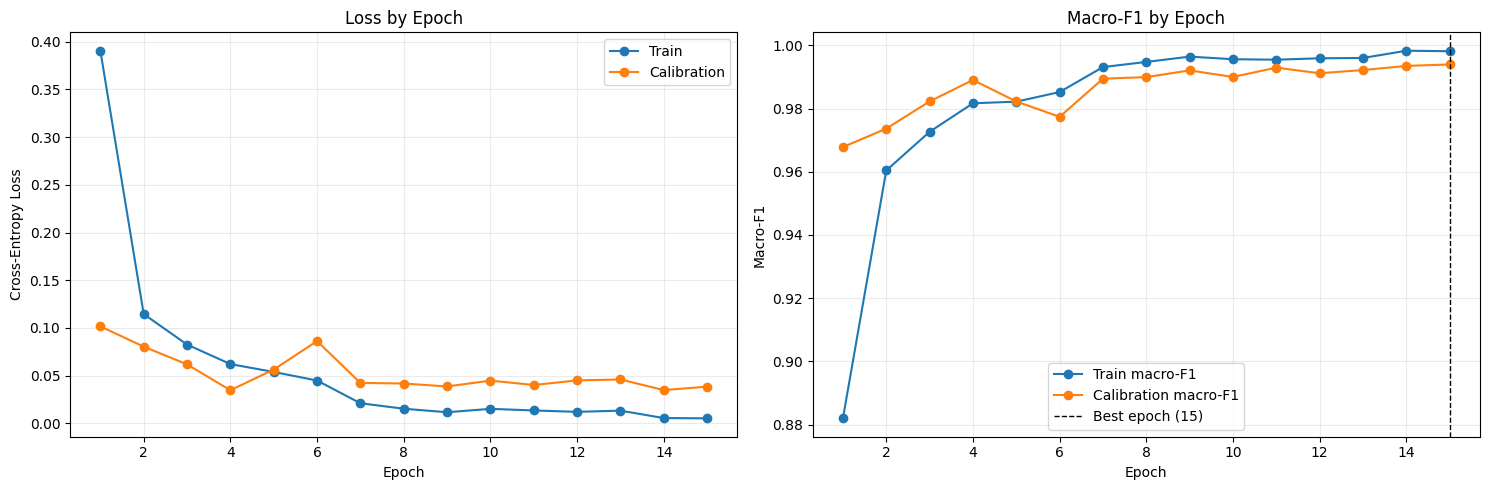

Saved: /kaggle/working/baseline_main19_outputs/figures/fig_03_baseline_learning_curves.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train"
)

axes[0].plot(
    history_df["epoch"],
    history_df["calibration_loss"],
    marker="o",
    label="Calibration"
)

axes[0].set_title("Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    history_df["epoch"],
    history_df["train_macro_f1"],
    marker="o",
    label="Train macro-F1"
)

axes[1].plot(
    history_df["epoch"],
    history_df["calibration_macro_f1"],
    marker="o",
    label="Calibration macro-F1"
)

axes[1].axvline(
    best_epoch,
    color="black",
    linestyle="--",
    linewidth=1,
    label=f"Best epoch ({best_epoch})"
)

axes[1].set_title("Macro-F1 by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro-F1")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()

learning_curve_path = FIG_DIR / "fig_03_baseline_learning_curves.png"
plt.savefig(learning_curve_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", learning_curve_path)

In [19]:
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

print("Reloaded best checkpoint.")
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Best calibration macro-F1:",
    round(best_checkpoint["best_calibration_macro_f1"], 5)
)

Reloaded best checkpoint.
Best epoch: 15
Best calibration macro-F1: 0.99395


In [20]:
final_calibration_metrics, final_calibration_outputs = evaluate_model(
    model=model,
    loader=calibration_loader,
    criterion=criterion,
    device=DEVICE
)

metrics_df = pd.DataFrame([{
    "split": "calibration",
    "loss": final_calibration_metrics["loss"],
    "accuracy": final_calibration_metrics["accuracy"],
    "balanced_accuracy": final_calibration_metrics["balanced_accuracy"],
    "macro_f1": final_calibration_metrics["macro_f1"],
    "best_epoch": best_epoch
}])

metrics_path = TABLE_DIR / "best_model_calibration_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

display(metrics_df)

print("Saved:", metrics_path)

Calibration:   0%|          | 0/100 [00:00<?, ?it/s]

,split,loss,accuracy,balanced_accuracy,macro_f1,best_epoch
0,calibration,0.038531,0.995934,0.993856,0.993952,15


Saved: /kaggle/working/baseline_main19_outputs/tables/best_model_calibration_metrics.csv


In [21]:
class_names = [
    index_to_class[index]
    for index in range(NUM_CLASSES)
]

calibration_report = classification_report(
    final_calibration_outputs["targets"],
    final_calibration_outputs["predictions"],
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

calibration_report_df = (
    pd.DataFrame(calibration_report)
    .transpose()
    .reset_index()
    .rename(columns={"index": "class_or_average"})
)

report_path = TABLE_DIR / "calibration_classification_report.csv"
calibration_report_df.to_csv(report_path, index=False)

display(calibration_report_df)

print("Saved:", report_path)

,class_or_average,precision,recall,f1-score,support
0,bell_pepper__bacterial_spot,1.000000,1.000000,1.000000,120.000000
1,bell_pepper__healthy,1.000000,1.000000,1.000000,178.000000
2,corn__cercospora_leaf_spot_gray_leaf_spot,0.936508,0.951613,0.944000,62.000000
3,corn__common_rust,1.000000,1.000000,1.000000,143.000000
4,corn__healthy,1.000000,1.000000,1.000000,139.000000
5,corn__northern_leaf_blight,0.974359,0.966102,0.970213,118.000000
6,potato__early_blight,1.000000,1.000000,1.000000,120.000000
7,potato__healthy,1.000000,1.000000,1.000000,18.000000
8,potato__late_blight,1.000000,0.991667,0.995816,120.000000
9,tomato__bacterial_spot,1.000000,0.992157,0.996063,255.000000


Saved: /kaggle/working/baseline_main19_outputs/tables/calibration_classification_report.csv


In [22]:
calibration_predictions_df = calibration_df[
    ["image_path", "label"]
].copy()

calibration_predictions_df["true_class_index"] = (
    final_calibration_outputs["targets"]
)

calibration_predictions_df["predicted_class_index"] = (
    final_calibration_outputs["predictions"]
)

calibration_predictions_df["predicted_label"] = [
    index_to_class[index]
    for index in final_calibration_outputs["predictions"]
]

calibration_predictions_df["confidence"] = (
    final_calibration_outputs["probabilities"].max(axis=1)
)

for class_index, class_name in index_to_class.items():
    calibration_predictions_df[
        f"probability_{class_index:02d}_{class_name}"
    ] = final_calibration_outputs["probabilities"][:, class_index]

calibration_predictions_path = (
    TABLE_DIR / "calibration_predictions_best_model.csv"
)

calibration_predictions_df.to_csv(
    calibration_predictions_path,
    index=False
)

display(calibration_predictions_df.head())

print("Saved:", calibration_predictions_path)

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,image_path,label,true_class_index,predicted_class_index,predicted_label,confidence,probability_00_bell_pepper__bacterial_spot,probability_01_bell_pepper__healthy,probability_02_corn__cercospora_leaf_spot_gray_leaf_spot,probability_03_corn__common_rust,...,probability_09_tomato__bacterial_spot,probability_10_tomato__early_blight,probability_11_tomato__healthy,probability_12_tomato__late_blight,probability_13_tomato__leaf_mold,probability_14_tomato__septoria_leaf_spot,probability_15_tomato__spider_mites_two_spotted_spider_mite,probability_16_tomato__target_spot,probability_17_tomato__tomato_mosaic_virus,probability_18_tomato__tomato_yellow_leaf_curl_virus
0,/kaggle/input/datasets/mohitsingh1804/plantvil...,potato__early_blight,6,6,potato__early_blight,1.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,/kaggle/input/datasets/mohitsingh1804/plantvil...,corn__healthy,4,4,corn__healthy,1.0,1.192093e-07,0.000002,7.152557e-07,2.384186e-07,...,9.536743e-07,5.364418e-07,1.084805e-05,5.364418e-07,1.013279e-06,5.960464e-08,7.152557e-07,3.576279e-07,5.364418e-07,2.980232e-07
2,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__late_blight,12,12,tomato__late_blight,1.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.251698e-06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__spider_mites_two_spotted_spider_mite,15,15,tomato__spider_mites_two_spotted_spider_mite,1.0,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,1.192093e-07,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,/kaggle/input/datasets/mohitsingh1804/plantvil...,tomato__tomato_yellow_leaf_curl_virus,18,18,tomato__tomato_yellow_leaf_curl_virus,1.0,7.748604e-07,0.000001,1.788139e-07,5.960464e-08,...,2.884865e-05,5.364418e-07,2.384186e-07,8.344650e-07,5.960464e-08,5.960464e-08,1.192093e-06,5.304813e-06,5.960464e-08,1.000000e+00


Saved: /kaggle/working/baseline_main19_outputs/tables/calibration_predictions_best_model.csv


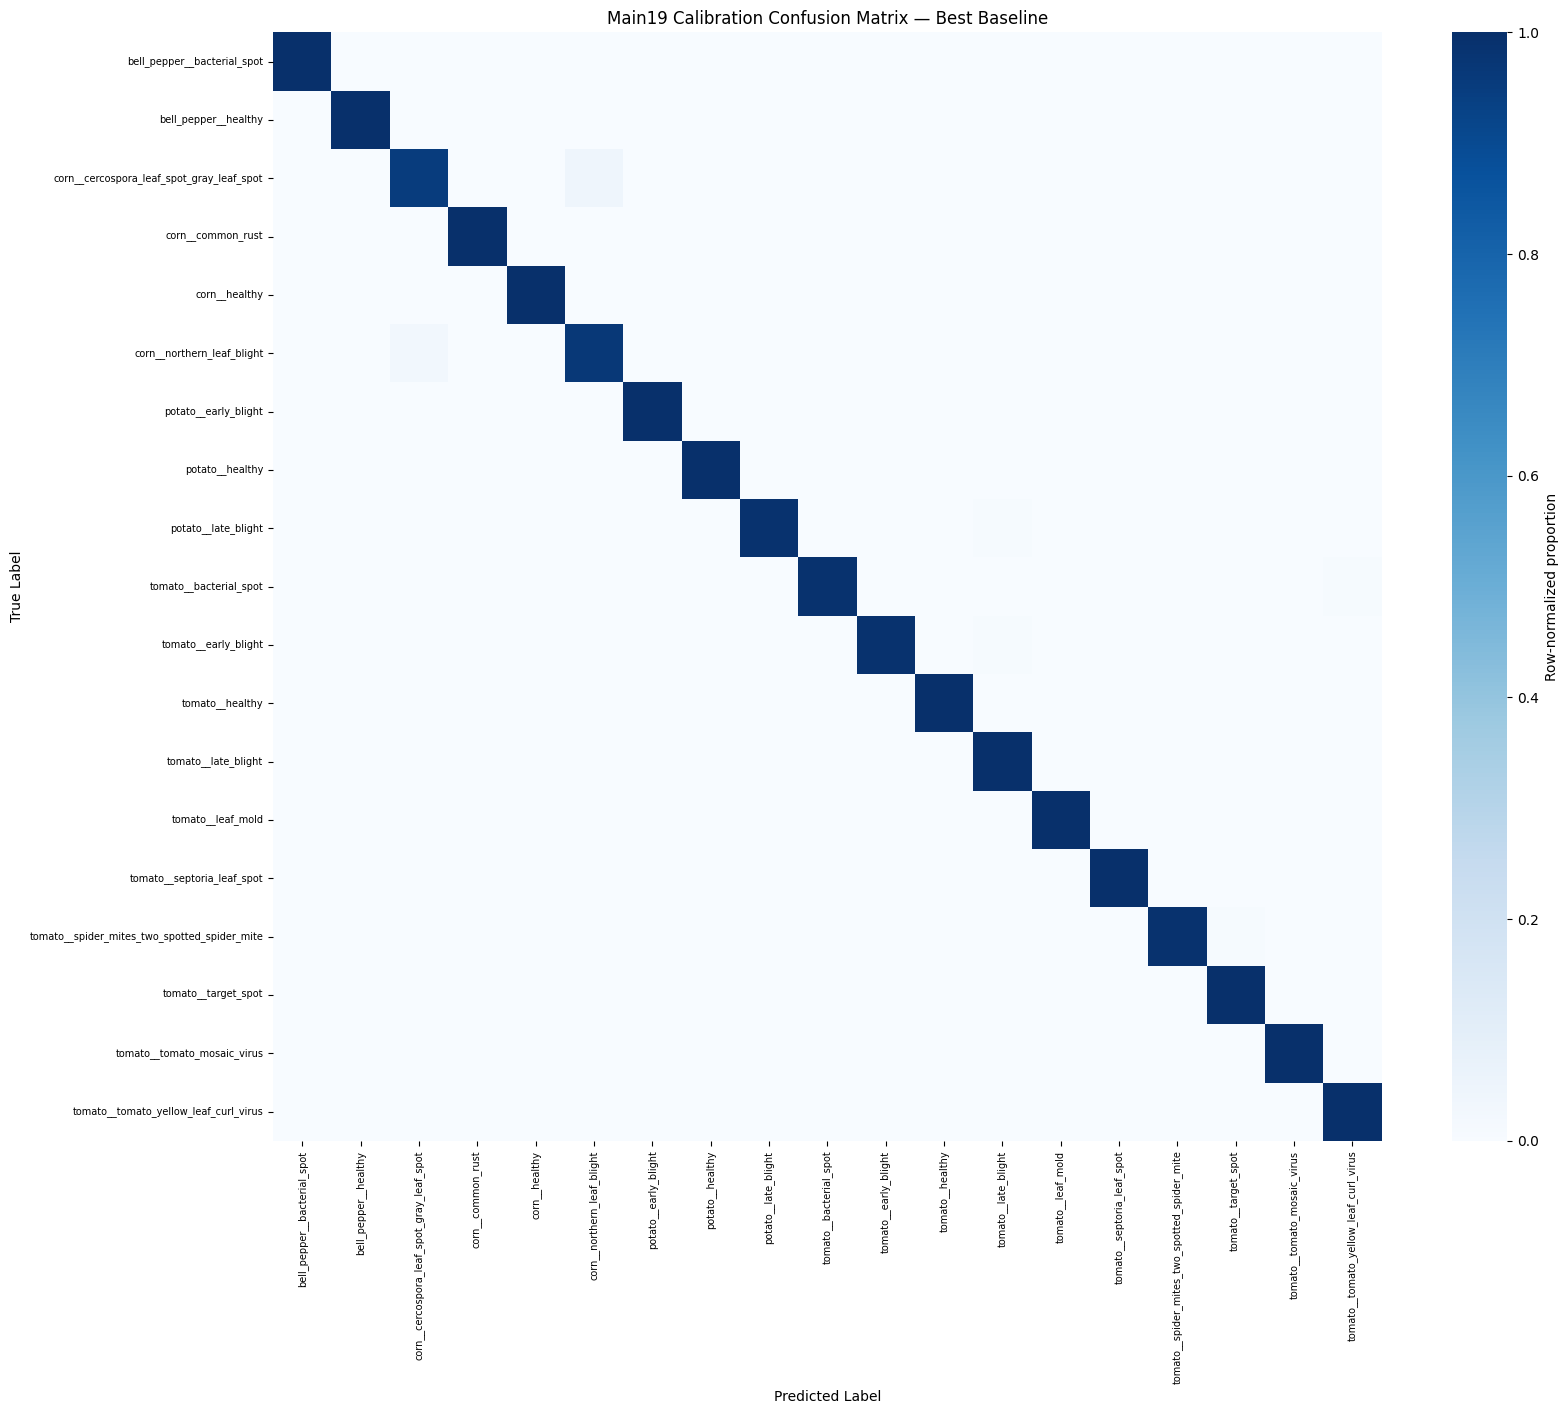

Saved: /kaggle/working/baseline_main19_outputs/figures/fig_04_calibration_confusion_matrix.png


In [23]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(
    final_calibration_outputs["targets"],
    final_calibration_outputs["predictions"],
    labels=list(range(NUM_CLASSES)),
    normalize="true"
)

plt.figure(figsize=(17, 14))

sns.heatmap(
    confusion,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    square=True,
    cbar_kws={"label": "Row-normalized proportion"}
)

plt.title("Main19 Calibration Confusion Matrix — Best Baseline")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()

confusion_path = FIG_DIR / "fig_04_calibration_confusion_matrix.png"
plt.savefig(confusion_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", confusion_path)

In [24]:
run_metadata = {
    "notebook": "03_baseline_classifier_main19",
    "completed_utc": datetime.now(timezone.utc).isoformat(),
    "best_epoch": int(best_epoch),
    "best_calibration_macro_f1": float(best_macro_f1),
    "final_calibration_metrics": {
        key: float(value)
        for key, value in final_calibration_metrics.items()
    },
    "checkpoint_path": str(best_checkpoint_path),
    "training_history_path": str(history_path),
    "internal_test_used": False,
    "python_version": platform.python_version(),
    "torch_version": torch.__version__,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

run_metadata_path = METADATA_DIR / "baseline_run_metadata.json"

with open(run_metadata_path, "w") as file:
    json.dump(run_metadata, file, indent=2)

print(json.dumps(run_metadata, indent=2))

{
  "notebook": "03_baseline_classifier_main19",
  "completed_utc": "2026-08-12T07:08:16.949400+00:00",
  "best_epoch": 15,
  "best_calibration_macro_f1": 0.9939520934929097,
  "final_calibration_metrics": {
    "loss": 0.03853119406053479,
    "accuracy": 0.9959336878323428,
    "balanced_accuracy": 0.9938555023928038,
    "macro_f1": 0.9939520934929097
  },
  "checkpoint_path": "/kaggle/working/baseline_main19_outputs/checkpoints/best_efficientnet_b0_main19.pt",
  "training_history_path": "/kaggle/working/baseline_main19_outputs/tables/training_history.csv",
  "internal_test_used": false,
  "python_version": "3.12.13",
  "torch_version": "2.10.0+cu128",
  "numpy_version": "2.0.2",
  "pandas_version": "2.3.3"
}


In [25]:
assert best_checkpoint_path.exists()
assert history_path.exists()
assert metrics_path.exists()
assert report_path.exists()
assert calibration_predictions_path.exists()
assert run_metadata_path.exists()

assert "internal_test" not in set(train_df["final_split"])
assert "internal_test" not in set(calibration_df["final_split"])

print("=" * 72)
print("NOTEBOOK 03 COMPLETED")
print("=" * 72)

print("\nBest baseline model")
print("Architecture: EfficientNet-B0")
print("Best epoch:", best_epoch)
print("Calibration macro-F1:", round(best_macro_f1, 5))

print("\nData usage")
print("Training images:", len(train_df))
print("Calibration images:", len(calibration_df))
print("Internal test images loaded: 0")

print("\nOutput directory")
print(OUTPUT_DIR)

print("\nNext notebook:")
print("04_temperature_scaling_and_internal_test_evaluation")
print("Do not evaluate on the internal-test manifest before that notebook.")

NOTEBOOK 03 COMPLETED

Best baseline model
Architecture: EfficientNet-B0
Best epoch: 15
Calibration macro-F1: 0.99395

Data usage
Training images: 18113
Calibration images: 3197
Internal test images loaded: 0

Output directory
/kaggle/working/baseline_main19_outputs

Next notebook:
04_temperature_scaling_and_internal_test_evaluation
Do not evaluate on the internal-test manifest before that notebook.
